# DSCI 216 Assignment 2
## Packet Data Analysis, Part I

**Student 1:**  
**Student 2:**  

Complete and submit one notebook per pair. Both students are responsible for understanding the entire submission and being able to explain its reasoning, code, results, and interpretations.

## Purpose and investigation process

In this assignment, you will examine data from Prof. Story's packet-loss experiments and evaluate three AI-generated claims. Read Prof. Story's packet-loss description before beginning.

Your investigation should follow this process:

**claim → investigative questions → evidence needed → probability concepts → computation → results → interpretation and evaluation**

A claim may lead to one or more investigative questions. One well-chosen question may be sufficient; use multiple questions when the claim contains multiple assertions that need separate investigation. 

## Claims to be evaluated

Keep all three claims in mind as you identify and interpret relevant variables during your initial exploration. Each claim is repeated later for easy reference.

> **AI Claim 1:** Packet loss is entirely caused by RcvBufErrors, indicating that the receiver's UDP buffer overflowed. Transfers fail exactly when there are a nonzero number of RcvBufErrors.

> **AI Claim 3:** Unlimited bitrate transfers are the least reliable. When a bitrate limit is imposed, higher bitrates are more reliable. Considering data from both experiments: Unlimited: 86.4% succeeded; 1 Gbit/sec: 99.8% succeeded; 750 Mbit/sec: 96.5% succeeded; 500 Mbit/sec: 90.4% succeeded.

> **AI Claim 4:** The main write method is the least reliable. Considering data from the write method experiment: main: 76.7% succeeded; helper: 99.9% succeeded; defer: 99.9% succeeded; asyncio: 99.9% succeeded.

## Files and setup

Place this notebook and the following files in the same folder:

- `write-method.2026-04-09-1220.csv`
- `max-payload.2026-03-31-1109.csv`

The setup cell below preserves the two datasets separately as `write` and `payload`. It also adds an `experiment` label before combining them as `both`, so the source of each row remains available.

In [3]:
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 50)
pd.options.display.float_format = "{:.4f}".format

write = pd.read_csv("write-method.2026-04-09-1220.csv")
payload = pd.read_csv("max-payload.2026-03-31-1109.csv")

write = write.assign(experiment="write_method")
payload = payload.assign(experiment="max_payload")
both = pd.concat([write, payload], ignore_index=True)

## Coding guidance

Keep your high-level computations clear, organized, and easy to follow. Use meaningful names and display results that directly address your investigative questions. Create and use helper functions when they improve clarity or reduce unnecessary repetition. You may add code and Markdown cells wherever they are useful.

# Part 1: Meet and understand the data

Use Prof. Story's description together with your own inspection of the datasets. Keep this exploration concise and focused on what you need for the three claims. Your interpretations are preliminary: return here and update them if your understanding changes while you investigate the claims.

## 1.1 Inspect the datasets

Examine the dimensions, columns, data types, and a few rows from each dataset. What initial similarities or differences do you notice? Do not draw conclusions about the claims yet.

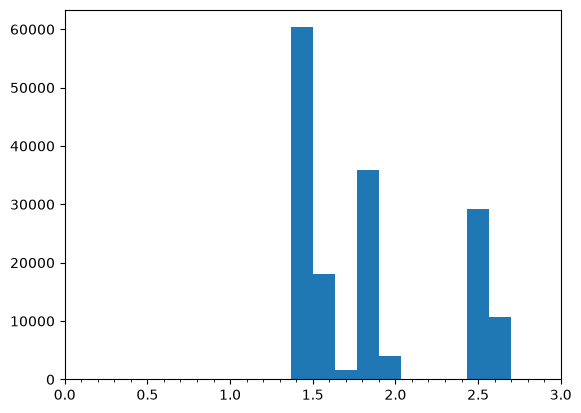

In [4]:
# Write your inspection code here.
import numpy as np
import matplotlib.pyplot as plt

# Dimensions, data types, sampling rows
write.shape
write.dtypes
write.sample(10)

# See all columns
write.columns

#Find out how trials were distributed across bitrates and write methods
write.loc[:, ["max_bitrate", "write_method"]].value_counts() # 10,000 for each combination (160K total)

# Investigate Rcvbuf Size
write.rcvbuf_size.value_counts()

# InDatagrams
write.InDatagrams.value_counts()

# Explore relationship between InErrors and RcvbufErrors
#plt.hist(write.InErrors, bins=13, density = True)
#plt.hist(write.RcvbufErrors, bins=13, density = True)
(write.InErrors == write.RcvbufErrors).all() # True, columns are the same

# Find relative frequencies of each number
write.RcvbufErrors.value_counts() / 160000 # 94% of trials had no errors
write.loc[write.RcvbufErrors != 0, "RcvbufErrors"].value_counts() / 9380 # 16 errors is the most common (65% of errors)

# Distribution of Duration
plt.hist(write.duration)
plt.xlim(0,3)
plt.xticks(ticks=np.arange(0,3,0.1), minor = True)
plt.show()

**Response:**  
The first difference that caught my eye with the two csv files is that the dimension for write_method.csv is signficantly larger than max-payload.csv, with write_method.csv containing 20,000 more dimensions than max-payload.csv. The columns and data types across each csv seem to be the same either being integers or floats. However, columns fed, redundancy, chunk_duration, chunk_max_packets, repair, and rcvbuf_size all seem to be NaN possibly being values written in hexadecimal instead of integers or floats. write_method.csv also had 4 more columns than max-payload.csv containing an extra defer, helper, asyncio, and main columns.

## 1.2 Interpret the observational unit and relevant variables

Based on the experiment description, the claims, and your inspection:

- Which variables appear relevant to the three claims? What does each represent, what role does it play, and what values can it take?
- Do any values require special interpretation?
- What does one row represent? Describe it in the context of the experiment.

You do not need to describe every column. Update or refine this response later if you learn more during the claim investigations.

In [5]:
# Inspect the variables and values needed to support your response.
write.max_bitrate.value_counts()
write.write_method.value_counts()
write.success.value_counts() / 160000


success
1   0.9414
0   0.0586
Name: count, dtype: float64

**Response:**  
1. Claim 1 indicate that the success column equals 0 if and only if RcvbufErrors != 0. We need to analyze the relationships between InErrors, RcvbufErrors, and success. Success (0/1) measures whether the trial was a successful data transfer or not. It is our main target variable. The two error columns are exactly the same in this dataset, but conceptually RcvbufErrors are a subset of InErrors. In this experiment, it appears that RcvBufErrors were the only type of error
2. Claim 3 requires us to analyze success in relation to the bitrate. Success is a binary variable while the max_bitrate takes on one of 4 categories. It is assumed that a max_bitrate of 0 actually means an unlimited bitrate.
3. Claim 4 requires us to analyze success in relation to the write method. Success is a binary variable while the write_method column is categorical with 4 potential values. The variables are easy to understand and evaluating the claim should be simple.

## 1.3 Understand the organization and readiness of the data

Use concise summaries to determine how trials are distributed across experiments and configurations. Check the key variables for missing, unusual, or encoded values. What features of the experimental design or data organization should you keep in mind when combining or comparing observations?

In [6]:
# Write the concise checks needed to support your response.
for col in write.columns:
    #print(col, ": ", write.loc[:, col].unique())
    col, ": ", write.loc[:, col].unique()
    
# Many columns have only one value or have many (>30), the columns with only a few values are likely different experiment configurations
# max_bitrate, write_method, tx_bytes, tx_packets, rx_bytes, rx_packets

# There would be equal trials of all experiment configurations, so we can figure out which of the candidate columns
# were really used as configuration variables
write.loc[:, ["max_bitrate", "write_method"]].value_counts()

# After checking all columns, only max_bitrate and write_method appear to be used to configure the experiment. There are 16
# combinations and 10,000 trials of each

# Neither variable has missing, unusual, or encoded values. This is important to keep in mind as we progress.

max_bitrate  write_method
500000000    defer           10000
             helper          10000
             asyncio         10000
             main            10000
750000000    defer           10000
             helper          10000
             asyncio         10000
             main            10000
1000000000   defer           10000
             helper          10000
             asyncio         10000
             main            10000
0            defer           10000
             helper          10000
             asyncio         10000
             main            10000
Name: count, dtype: int64

**Response:**  
We seek to understand how the 160,000 trials are distributed across different experimental configurations. Therefore, we examine the data for which variables have only a few values (but >1) and check how many trials have a certain configuration of those variables. If the trials are evenly distributed across the variables, those are likely different experimental configurations. After checking the 6 different candidates, the trials were only equally distributed across the max_bitrate and write_method variables. Those 2 variables form 16 different experimental configurations, each having 10,000 trials in the dataset.

# Part 2: Claim 1 — RcvBufErrors and transfer failures

> **AI Claim 1:** Packet loss is entirely caused by RcvBufErrors, indicating that the receiver's UDP buffer overflowed. Transfers fail exactly when there are a nonzero number of RcvBufErrors.

The CSV column is named `RcvbufErrors`.

## 2.1 Investigative question

For this first claim, an investigative question is provided as a model:

> **What relationship do the observed data show between `RcvbufErrors` and transfer failure, and does that relationship support the claim that `RcvbufErrors` fully explains packet loss?**

Briefly explain how this question captures the important parts of the claim.

**Response:**  
Write your response here.

## 2.2 Evidence and probability reasoning

1. What evidence would you need to answer the investigative question and evaluate the claim?
2. What probability concepts are related to this evidence? Explain how they are related.

**Response:**  
Write your response here.

## 2.3 Obtain the evidence

Use the data to obtain the evidence you identified. Your code and displayed results should make it clear how the evidence answers the investigative question.

In [7]:
# Write your Claim 1 analysis here. Add cells if needed.

## 2.4 Results, interpretation, and evaluation

- What did you find? Report the results needed to answer your investigative question.
- What conclusion is supported by your evidence?
- Evaluate the AI claim: Are any stated calculations correct? Is the evidence appropriate and sufficient? Is the conclusion justified?
- If the claim is not fully justified, revise it to state a conclusion that the evidence supports.

**Response:**  
Write your response here.

# Part 3: Claim 3 — bitrate and reliability

> **AI Claim 3:** Unlimited bitrate transfers are the least reliable. When a bitrate limit is imposed, higher bitrates are more reliable. Considering data from both experiments: Unlimited: 86.4% succeeded; 1 Gbit/sec: 99.8% succeeded; 750 Mbit/sec: 96.5% succeeded; 500 Mbit/sec: 90.4% succeeded.

## 3.1 Formulate the investigative question(s)

This claim contains reported numerical results and broader conclusions about bitrate and reliability. Write one or more investigative questions that would allow you to evaluate the important parts of the claim using the available data. Briefly explain how your question or questions connect to the claim.

**Investigative question(s) and explanation:**  
Write your response here.

## 3.2 Evidence and probability reasoning

1. What evidence would you need to answer your investigative question(s) and evaluate the claim?
2. What probability concepts are related to this evidence? Explain how they are related.

**Response:**  
Write your response here.

## 3.3 Obtain the evidence

Use the data to obtain the evidence you identified. Your code and displayed results should make it clear how the evidence answers your investigative question(s).

In [8]:
# Write your Claim 3 analysis here. Add cells if needed.

## 3.4 Results, interpretation, and evaluation

- What did you find? Report the results needed to answer your investigative question(s).
- What conclusion is supported by your evidence?
- Evaluate the AI claim: Are its stated calculations correct? Is its evidence appropriate and sufficient? Is its conclusion justified?
- If the claim is not fully justified, revise it to state a conclusion that the evidence supports.

**Response:**  
Write your response here.

# Part 4: Claim 4 — write method and reliability

> **AI Claim 4:** The main write method is the least reliable. Considering data from the write method experiment: main: 76.7% succeeded; helper: 99.9% succeeded; defer: 99.9% succeeded; asyncio: 99.9% succeeded.

## 4.1 Formulate the investigative question(s)

Translate the claim into one or more investigative questions that can be answered using the available data. Briefly explain how your question or questions capture the important parts of the claim.

**Investigative question(s) and explanation:**  
Write your response here.

1. What is the observed success rate for each write_method value in the write_method experiment and is the main column the lowest?
This question aims to see if the claim "least reliable" is supported empirically and to see if the percentages
for each column actually represeant the raw data of the column.

2. Does main perform worse across the entire dataset or does it perform worse depending on the bitrate or some other condition? 
This question aims to see if main's performance is truly unreliable across the entire dataset or if certain conditions such as the amount of bitrate being tested pull down the average.

## 4.2 Evidence and probability reasoning

1. What evidence would you need to answer your investigative question(s) and evaluate the claim?
2. What probability concepts are related to this evidence? Explain how they are related rather than only listing terms.

**Response:**  
1. For evidence we would need the success rate for each write_method group along with the group sizes which when combined
should give main the 76.7% success rate, this tackles question 1. The second evidence we would need is to break down
the success rate while grouping write_method with max_bitrate to see if main's performance is uniform across all
bitrates or concentrated in specific settings. 

2. The two probability concepts related to the evidence is Conditional and Joint probability. The first question is essentially asking for the joint probability of success and main divided by the total number of successes to find the success rate of main. The second question can be written as P(success | (write_method=main, max_bitrate)) vs P(success | (write_method=other, max_bitrate)) since we are investigating if main performs worse at certain bitrates or the entire dataset.

## 4.3 Obtain the evidence

Use the data to obtain the evidence you identified. Your code and displayed results should make it clear how the evidence answers your investigative question(s).

In [9]:
# Write your Claim 4 analysis here. Add cells if needed.

 #1. Calculate observed success rates for each write_method
print("=" * 60)
print("EVIDENCE FOR CLAIM 4: Write Method and Reliability")
print("=" * 60)

# Question 1: Overall success rates by write_method
print("\n--- Question 1: Overall Success Rates by Write Method ---")
write_method_success = write.groupby('write_method').agg(
    successes=('success', 'sum'),
    total_trials=('success', 'count'),
    success_rate=('success', lambda x: (x.sum() / x.count()) * 100)
).reset_index()
display(write_method_success)

# Also show the raw counts to verify the percentages
print("\nRaw counts verification:")
print(f"Total trials for main: {write_method_success[write_method_success['write_method'] == 'main']['total_trials'].values[0]}")
print(f"Success count for main: {write_method_success[write_method_success['write_method'] == 'main']['successes'].values[0]}")
print(f"Calculated success rate for main: {write_method_success[write_method_success['write_method'] == 'main']['success_rate'].values[0]:.1f}%")

# Question 2: Performance breakdown by bitrate and write_method
print("\n--- Question 2: Success Rates by Write Method and Max Bitrate ---")
write_bitrate_success = write.groupby(['write_method', 'max_bitrate']).agg(
    successes=('success', 'sum'),
    total_trials=('success', 'count'),
    success_rate=('success', lambda x: (x.sum() / x.count()) * 100)
).reset_index()

# Pivot for easier viewing
bitrate_pivot = write_bitrate_success.pivot(
    index='write_method',
    columns='max_bitrate',
    values='success_rate'
).round(1)

print("\nSuccess rates (%) by write_method and max_bitrate:")
display(bitrate_pivot)

# Also show the count of trials in each cell to check for small samples
trial_count_pivot = write_bitrate_success.pivot(
    index='write_method',
    columns='max_bitrate',
    values='total_trials'
)
print("\nNumber of trials in each group:")
display(trial_count_pivot)

EVIDENCE FOR CLAIM 4: Write Method and Reliability

--- Question 1: Overall Success Rates by Write Method ---


,write_method,successes,total_trials,success_rate
0,asyncio,39988,40000,99.9700
1,defer,39993,40000,99.9825
2,helper,39973,40000,99.9325
3,main,30663,40000,76.6575



Raw counts verification:
Total trials for main: 40000
Success count for main: 30663
Calculated success rate for main: 76.7%

--- Question 2: Success Rates by Write Method and Max Bitrate ---

Success rates (%) by write_method and max_bitrate:


max_bitrate,0,500000000,750000000,1000000000
write_method,,,,
asyncio,99.9000,100.0000,100.0000,100.0000
defer,99.9000,100.0000,100.0000,100.0000
helper,99.8000,100.0000,100.0000,99.9000
main,99.6000,32.6000,75.3000,99.1000



Number of trials in each group:


max_bitrate,0,500000000,750000000,1000000000
write_method,,,,
asyncio,10000,10000,10000,10000
defer,10000,10000,10000,10000
helper,10000,10000,10000,10000
main,10000,10000,10000,10000


## 4.4 Results, interpretation, and evaluation

- What did you find? Report the results needed to answer your investigative question(s).
- What conclusion is supported by your evidence?
- Evaluate the AI claim: Are its stated calculations correct? Is its evidence appropriate and sufficient? Is its conclusion justified?
- If the claim is not fully justified, revise it to state a conclusion that the evidence supports.

**Response:**  
The results reported that:
- Main's success rate was indeed 76.7%
- Main when tested under different bitrates performed
significantly worse than the other write methods.

While on average main performs worse than the other write methods, main is not uniformly reliable. Main's low overalle is success rate is driven almost entirely by two specific bitrate settings as at unlimited bitrate main succeeds 99.6% and on 1 Gbit/s main succeeds 99.1% of the time. However, on lower bitrates such as 500 Mbit/s and 750 Mbit/s the success rate plummits to 32.6% and 75.3% respectively. Therefore, main's poor 76.7% isn't a general property of the method, but instead a specific faliure that only appears in lower bitrates.

# Part 5: Overall synthesis

Using examples from your investigations, explain the difference between:

- a numerically correct calculation,
- appropriate and sufficient evidence, and
- a justified conclusion.

**Response:**  
Write your response here.

- a numerical calculation is just a number, it needs an 

# Part 6: Collaboration and AI-use record

Complete this section jointly as a pair.

1. Briefly describe how you organized your collaboration.
2. Identify any AI tools used and explain what they were used for. If the partners used AI differently, describe each person's use separately. If you did not use AI, state that.
3. If AI was used, how did you review, test, or verify any AI-assisted work?

**Response:**  
Write your response here.

# Part 7: Individual reflections

Each student must write a separate response. In a paragraph, describe one important thing you learned from this assignment about asking questions, selecting appropriate evidence, using probability concepts, or interpreting computational results. 

## Student 1 reflection

**Name:**  

Write your individual reflection here.

## Student 2 reflection

**Name:**  

Write your individual reflection here.

# Before submitting

- Confirm that both students' names appear at the top.
- Restart the kernel and run all cells from beginning to end.
- Submit one completed `.ipynb` file for the pair.